# Zero-shot DSR using DynaMix


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.append('..')

from src.model.dynamix import DynaMix
from src.model.forecaster import DynaMixForecaster
from src.metrics.metrics import geometrical_misalignment, temporal_misalignment, MASE
from src.utilities.plotting_eval import plot_3D_attractor, plot_2D_attractor, plot_TS_forecast
from src.utilities.utilities import load_hf_model

## Dysts Benchmarks

In [ ]:
from dysts.metrics import smape


def vpt_smape(x, xhat, threshold=30):
    """
    Find the first time index at which an array exceeds a threshold.

    Args:
        x (np.ndarray): The ground truth, a time series of shape (nt, 1).
        xhat (np.ndarray): The forecast, a time series of shape (nt, 1).
        threshold (float): The threshold to search for.

    Returns:
        int: The first time index at which the array exceeds the threshold.
    """
    arr = horizoned_smape(x, xhat)
    exceed_times = np.where(arr > threshold)[0]
    if len(exceed_times) == 0:
        tind = len(arr)
    else:
        tind = exceed_times[0]
    return tind

def horizoned_smape(x, xhat):
    """Given a horizoned forecast and ground truth, compute the SMAPE as a function of time"""
    nt = min(x.shape[0], xhat.shape[0])
    smape_vals = list()
    for i in range(1, nt+1):
        smape_vals.append(smape(x[:i], xhat[:i]))
    smape_vals = np.array(smape_vals)
    return smape_vals

In [ ]:
import glob
import os
# context_path
context_paths = sorted(glob.glob("/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/context_*context.npy"))
output_dir= "/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/dynamix_context_512_granularity_30/"
# ground_truth_paths = sorted(glob.glob("/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/forecast_*.npy"))

# Load the pre-trained model
model = load_hf_model("dynamix-3d-alrnn-v1.0")
model.eval() # Set model to evaluation mode
forecaster = DynaMixForecaster(model) # Initialize the forecaster

## Store the metrics
all_all_smape_rolling = list()
all_all_vpt = list()
all_all_cdim_true = list()
all_all_cdim_pred = list()
all_all_kl_dist = list()

for context_path in context_paths[:]:
    context_traj = np.load(context_path)
    fname = os.path.split(context_path)[1]
    eq_name = fname.split("_")[1]
    print(eq_name, flush=True)

    ## Load context and make tensor
    context_traj_tensor = torch.tensor(context_traj, dtype=torch.float32)
    context_traj_tensor = torch.transpose(context_traj_tensor, 0, 1)

    ## Get ground truth
    ground_truth_path = f"/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/forecast_{eq_name}_granularity30_true_chronos_test.npy"
    ground_truth = np.load(ground_truth_path)
    ground_truth_tensor = torch.tensor(ground_truth, dtype=torch.float32)

    ## Make DynaMix prediction
    with torch.no_grad(): 
        reconstruction = forecaster.forecast(
            context=context_traj_tensor,
            horizon=ground_truth.shape[1], # Match the horizon of the ground truth
            standardize=True,
        )
    reconstruction = torch.transpose(reconstruction, 0, 1)


    ## Make output path and save reconstruction to it
    output_path = os.path.join(output_dir, f"dynamix_{eq_name}_large_granularity30.npy")
    np.save(output_path, reconstruction.detach().numpy(), allow_pickle=True)



    ### Error metrics
    all_traj_true = ground_truth_tensor.detach().numpy()
    all_traj_forecasts = reconstruction.detach().numpy()

    ## Compute horizoned smape
    all_smape_rolling = list()
    all_vpt = list()
    for traj_pred, traj_true in zip(all_traj_forecasts, all_traj_true):
        all_smape = [horizoned_smape(traj_true[:, i], traj_pred[:, i]) for i in range(traj_pred.shape[1])]
        all_smape_rolling.append(all_smape)
        all_vpt.append(vpt_smape(traj_pred.squeeze(), traj_true.squeeze()))
    all_smape_rolling = np.array(all_smape_rolling)
    all_vpt = np.array(all_vpt)
    ## Across replicate initial conditions, take median
    ## Across different dimensions, take mean
    averaged_smape_rolling = np.nanmean(np.copy(all_smape_rolling), axis=1)

    cdim_true, cdim_pred = gp_dim(np.vstack(all_traj_true)), gp_dim(np.vstack(all_traj_forecasts).squeeze())

    kl_dist = estimate_kl_divergence(np.vstack(all_traj_true).squeeze(), np.vstack(all_traj_forecasts).squeeze())
    if np.isinf(kl_dist):
        kl_dist = np.nan

    all_all_smape_rolling.append(averaged_smape_rolling)
    all_all_vpt.append(np.nanmean(all_vpt))
    all_all_cdim_true.append(cdim_true)
    all_all_cdim_pred.append(cdim_pred)
    all_all_kl_dist.append(kl_dist)

all_all_smape_rolling = np.array(all_all_smape_rolling)
all_all_vpt = np.array(all_all_vpt)
all_all_kl_dist = np.array(all_all_kl_dist)
from scipy.stats import spearmanr
scorr_val = spearmanr(all_all_cdim_true, all_all_cdim_pred).statistic
scorr_val_err = 1 / np.sqrt(len(all_all_cdim_true) - 1 )



Aizawa
AnishchenkoAstakhov
Arneodo
ArnoldBeltramiChildress
ArnoldWeb
AtmosphericRegime


/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/numpy/_core/function_base.py:140: RuntimeWarning: invalid value encountered in subtract
  delta = np.subtract(stop, start, dtype=type(dt))


BeerRNN
BelousovZhabotinsky
BickleyJet
Blasius
BlinkingRotlet
BlinkingVortex
Bouali2
Bouali
BurkeShaw
CaTwoPlusQuasiperiodic
CaTwoPlus
CellCycle
CellularNeuralNetwork
ChenLee


/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


Chen
Chua
CircadianRhythm
CoevolvingPredatorPrey
Colpitts
Coullet
Dadras
DequanLi
DoubleGyre


/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/dysts/metrics.py:543: RuntimeWarning: divide by zero encountered in divide
  log_ratios = np.log(p_hat(selected_samples) / q_hat(selected_samples))
/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/dysts/metrics.py:543: RuntimeWarning: overflow encountered in divide
  log_ratios = np.log(p_hat(selected_samples) / q_hat(selected_samples))


DoublePendulum
Duffing
ExcitableCell
Finance
FluidTrampoline
ForcedBrusselator
ForcedFitzHughNagumo
ForcedVanDerPol
GenesioTesi
GuckenheimerHolmes
Hadley
Halvorsen
HastingsPowell
HenonHeiles
HindmarshRose
Hopfield
HyperBao
HyperCai
HyperJha
HyperLorenz
HyperPang
HyperQi
HyperRossler
HyperWang
HyperXu
HyperYan
HyperYangChen
IsothermalChemical
ItikBanksTumor
JerkCircuit
KawczynskiStrizhak
Laser
LidDrivenCavityFlow
LiuChen
Lorenz84
Lorenz96
LorenzBounded
LorenzCoupled
LorenzStenflo
Lorenz
LuChenCheng
LuChen
MacArthur
MooreSpiegel
MultiChua
NewtonLiepnik
NoseHoover
NuclearQuadrupole
OscillatingFlow
PanXuZhou
PehlivanWei
QiChen
Qi
RabinovichFabrikant
RayleighBenard
RikitakeDynamo
Rossler
Rucklidge
Sakarya
SaltonSea
SanUmSrisuchinwong
ShimizuMorioka
SprottA
SprottB
SprottC
SprottD
SprottE
SprottF
SprottG
SprottH
SprottI
SprottJ
SprottJerk
SprottK
SprottL
SprottM
SprottMore
SprottN
SprottO
SprottP
SprottQ
SprottR
SprottS
SprottTorus


In [85]:


## save to npz file
# np.savez("all_all_metrics.npz", smape_rolling=all_all_smape_rolling, vpt=all_all_vpt, kl_dist=all_all_kl_dist, corrdim_corr=scorr_val, corrdim_corr_err=scorr_val_err)

out = np.load("all_all_metrics.npz", allow_pickle=True)
smape_rolling = out["smape_rolling"]
all_vpt = out["vpt"]
kl_dist = out["kl_dist"]
corrdim_corr = out["corrdim_corr"]
corrdim_corr_err = out["corrdim_corr_err"]




In [74]:
out["smape_rolling"].shape

(113, 20, 300)

In [ ]:
# from scripts.utils import smape_rolling, vpt_smape







In [52]:
kl_dist

np.float64(0.043526874570407645)

## Load Model

In [6]:
# Load the pre-trained model
model = load_hf_model("dynamix-3d-alrnn-v1.0")

# Set model to evaluation mode
model.eval()

# Initialize the forecaster
forecaster = DynaMixForecaster(model)

config_3d-alrnn-v1.0.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

dynamix-3d-alrnn-v1.0.safetensors:   0%|          | 0.00/44.2k [00:00<?, ?B/s]

## 3D Dynamical Systems Reconstruction

In [7]:
# Forecasting Hyperparameters
CL = 2000  # Context length
T = 10000  # Prediction length

# Load data
data = np.load("test_data/lorenz63.npy")
context = data[:CL,:]
ground_truth = data[CL:CL+T,:]

print(f"Data shape: {data.shape}")
print(f"Context shape: {context.shape}")
print(f"Ground truth shape: {ground_truth.shape}")

Data shape: (12000, 3)
Context shape: (2000, 3)
Ground truth shape: (10000, 3)


In [27]:
context_tensor = torch.tensor(context, dtype=torch.float32)

# Make prediction using the forecasting pipeline
with torch.no_grad():  # No gradient tracking needed for inference
    reconstruction = forecaster.forecast(
        context=context_tensor,
        horizon=T,
        standardize=True,
    )
    
# Convert back to numpy for evaluation and plotting
reconstruction_np = reconstruction.cpu().numpy()
print("Prediction shape: ", reconstruction_np.shape)

Prediction shape:  (10000, 3)


Geometrical Disagreement: D_stsp = 0.955300
Temporal Disagreement: D_H = 0.079834
Prediction Error: MASE = 0.408059


/Users/william/program_repos/dynamix_baseline/DynaMix-python-main/notebooks/../src/utilities/plotting_eval.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


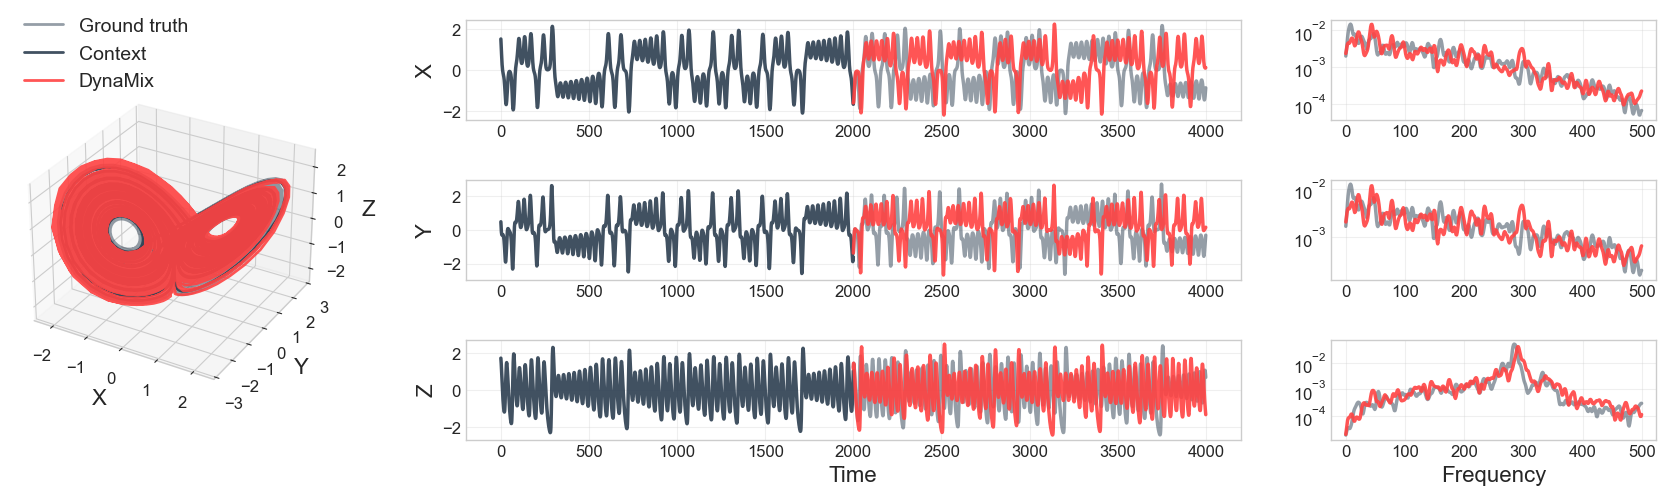

In [ ]:
ground_truth_tensor = torch.tensor(ground_truth[:T,:], dtype=torch.float32)
reconstruction_tensor = torch.tensor(reconstruction_np[:T,:], dtype=torch.float32)

# Calculate metrics
bins = 30
smoothing = 20
mase_steps = 10

dstsp = geometrical_misalignment(reconstruction_tensor, ground_truth_tensor, n_bins=bins)
dh = temporal_misalignment(reconstruction_tensor, ground_truth_tensor, smoothing=smoothing)
pe = MASE(ground_truth_tensor, reconstruction_tensor, steps=mase_steps)

print(f"Geometrical Disagreement: D_stsp = {dstsp:.6f}")
print(f"Temporal Disagreement: D_H = {dh:.6f}")
print(f"Prediction Error: MASE = {pe:.6f}")

# Visualize the 3D attractor with time series and power spectrum
fig = plot_3D_attractor(context[:CL,:], reconstruction_np[:,:], ground_truth=ground_truth[:T,:],lim_pse=500)
plt.show()

In [43]:
context_path = "/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/context_Aizawa_granularity30_true_chronos_context.npy"
context_traj = np.load(context_path)
context_traj.shape
context_traj_tensor = torch.tensor(context_traj, dtype=torch.float32)
context_traj_tensor.shape

# granularity30_true_chronos_test
forecast_path = "/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/forecast_Aizawa_granularity30_true_chronos_test.npy"
forecast_traj = np.load(forecast_path)
forecast_traj.shape
forecast_traj_tensor = torch.tensor(forecast_traj, dtype=torch.float32)
forecast_traj_tensor.shape


forecast_path = "/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/chronos_benchmarks_context_512_granularity_30/forecast_Aizawa_large_granularity30.npy"
chronos_traj = np.load(forecast_path)
chronos_traj.shape
chronos_traj_tensor = torch.tensor(chronos_traj, dtype=torch.float32)



Lorenz


300

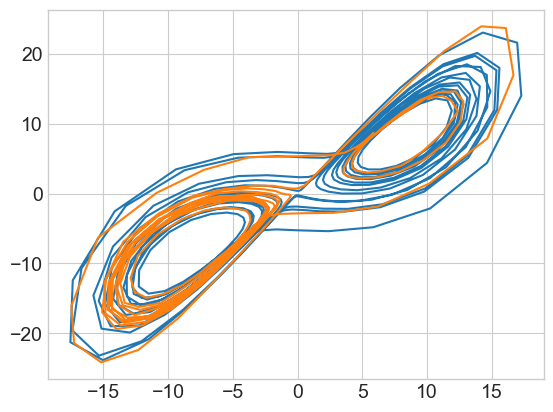

In [103]:
plt.plot(context_traj_tensor[:, 0, 0], context_traj_tensor[:, 0, 1], label="Context")
plt.plot(reconstruction[0, :, 0], reconstruction[0, :, 1], label="DynaMix")

In [ ]:
import os
# context_path
# '/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/context_Aizawa_granularity30_true_chronos_context.npy'



Aizawa


In [ ]:
.shape

torch.Size([20, 300, 3])

In [79]:
forecast_traj_tensor.shape

torch.Size([20, 300, 3])

In [ ]:
context_traj_tensor = torch.transpose(context_traj_tensor, 0, 1).shape

In [68]:
?forecaster.forecast

Signature:
forecaster.forecast(
    context,
    horizon,
    preprocessing_method='pos_embedding',
    standardize=True,
    fit_nonstationary=False,
    initial_x=None,
)
Docstring:
Efficient batched forecasting with the DynaMix model.

This method implements a complete forecasting pipeline including:
- Data preprocessing (Box-Cox, detrending, standardization)
- Embedding techniques for dimensionality matching
- DynaMix model prediction
- Data postprocessing (inverse transformations)

Args:
    context: Context data tensor of shape (seq_length, batch_size, feature_dim) or (seq_length, feature_dim)
    horizon: Forecast horizon (number of steps to predict)
    preprocessing_method: Data preprocessing method ('pos_embedding', 'zero_embedding',
                          'delay_embedding', or 'delay_embedding_random') (default: 'pos_embedding')
    standardize: Whether to standardize the data (default: True)
    fit_nonstationary: Whether to fit a non-stationary time series (default: Fal

In [71]:
context_traj_tensor.shape

torch.Size([20, 512, 3])

In [ ]:
all_reconstructions = []
for context_tensor in context_traj_tensor:
    context_tensor = torch.tensor(context_tensor, dtype=torch.float32)

    # Make prediction using the forecasting pipeline
    with torch.no_grad():  # No gradient tracking needed for inference
        reconstruction = forecaster.forecast(
            context=context_tensor,
            horizon=T,
            standardize=True,
        )
    all_reconstructions.append(reconstruction.cpu().numpy())
all_reconstructions = np.array(all_reconstructions)
output_path = "/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/dynamix_context_512_granularity_30/forecast_Aizawa_large_granularity30_reconstructions.npy"



/var/folders/79/zct6q7kx2yl6b1ryp2rsfbtc0000gr/T/ipykernel_9402/2559957968.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  context_tensor = torch.tensor(context_tensor, dtype=torch.float32)


In [37]:
forecast_traj_tensor.shape

torch.Size([20, 300, 3])

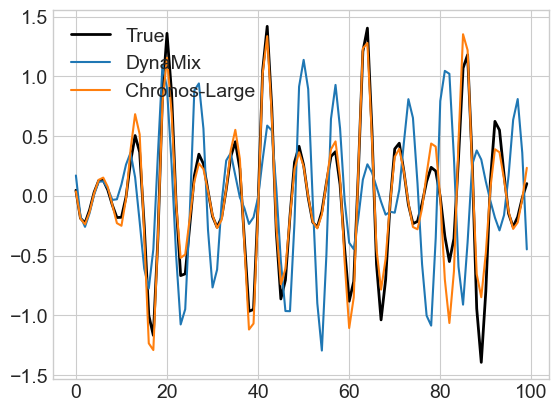

In [46]:
plt.plot(forecast_traj_tensor[0, :100, 0], label="True", color="black", linewidth=2)
plt.plot(reconstruction.cpu().numpy()[:100, 0], label="DynaMix")
plt.plot(chronos_traj_tensor[0, :100, 0], label="Chronos-Large")
plt.legend()

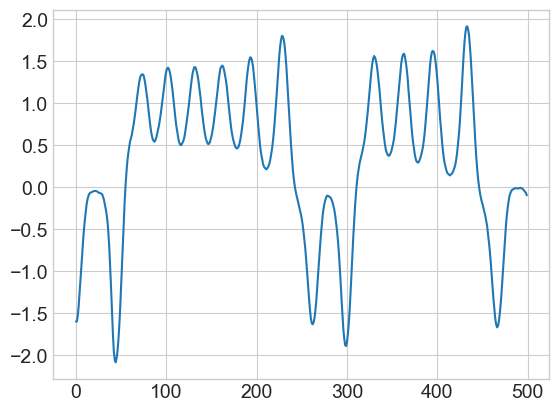

In [31]:
plt.plot(reconstruction_np[:500, 0])

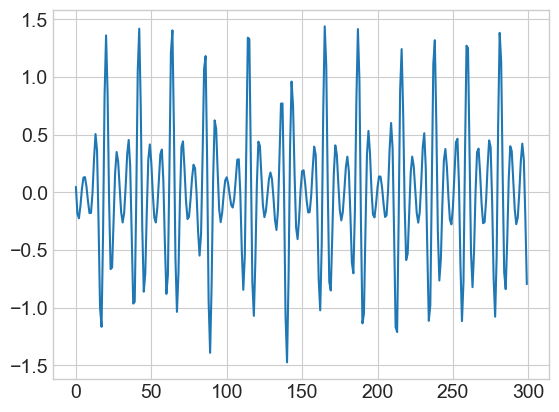

In [20]:
plt.plot(forecast_traj[0, :, 0])

In [6]:
# Forecasting Hyperparameters
CL = 1028  # Context length
T = 10000  # Prediction length

# Load data
data = np.load("test_data/chua.npy")
context = data[:CL,:]
ground_truth = data[CL:CL+T,:]

print(f"Data shape: {data.shape}")
print(f"Context shape: {context.shape}")
print(f"Ground truth shape: {ground_truth.shape}")

Data shape: (12000, 3)
Context shape: (1028, 3)
Ground truth shape: (10000, 3)


In [7]:
context_tensor = torch.tensor(context, dtype=torch.float32)

# Make prediction using the forecasting pipeline
with torch.no_grad():  # No gradient tracking needed for inference
    reconstruction = forecaster.forecast(
        context=context_tensor,
        horizon=T,
        standardize=True,
    )
    
# Convert back to numpy for evaluation and plotting
reconstruction_np = reconstruction.cpu().numpy()
print("Prediction shape: ", reconstruction_np.shape)

Prediction shape:  (10000, 3)


Geometrical Disagreement: D_stsp = 2.205967
Temporal Disagreement: D_H = 0.087704
Prediction Error: MASE = 0.365661


/export/home/chemmer/code/zero-shot-DSR/zero-shot-DSR-python/notebooks/../src/utilities/plotting_eval.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


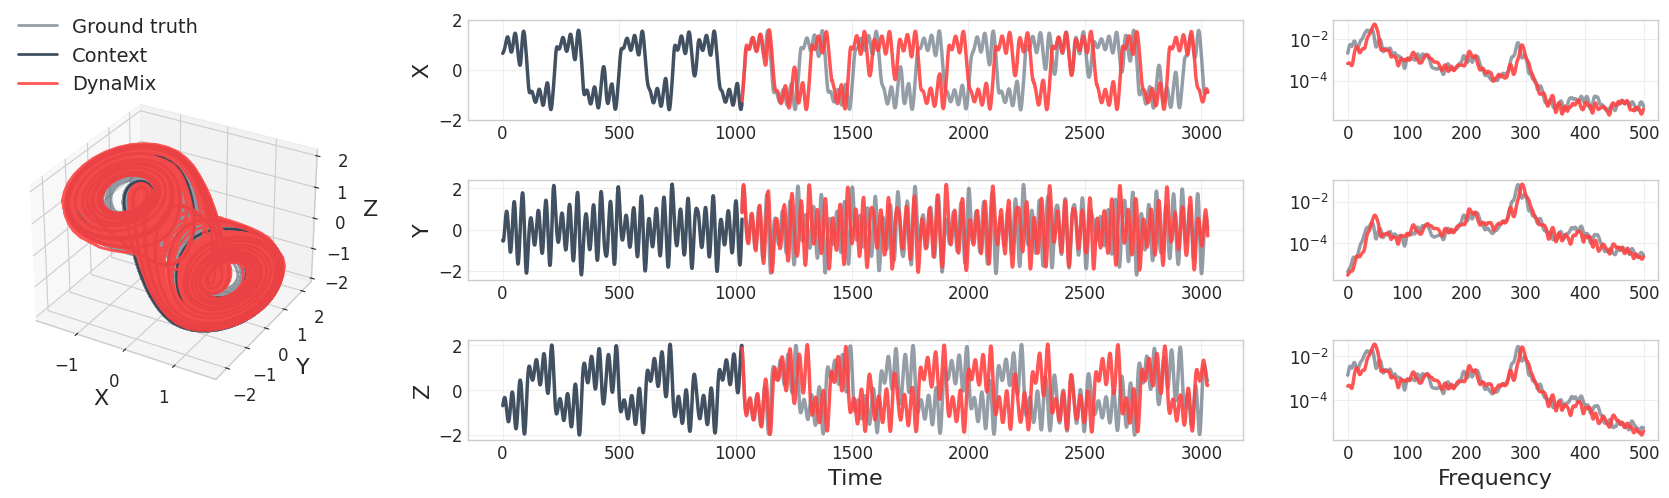

In [8]:
ground_truth_tensor = torch.tensor(ground_truth[:T,:], dtype=torch.float32)
reconstruction_tensor = torch.tensor(reconstruction_np[:T,:], dtype=torch.float32)

# Calculate metrics
bins = 30
smoothing = 20
mase_steps = 10

dstsp = geometrical_misalignment(reconstruction_tensor, ground_truth_tensor, n_bins=bins)
dh = temporal_misalignment(reconstruction_tensor, ground_truth_tensor, smoothing=smoothing)
pe = MASE(ground_truth_tensor, reconstruction_tensor, steps=mase_steps)

print(f"Geometrical Disagreement: D_stsp = {dstsp:.6f}")
print(f"Temporal Disagreement: D_H = {dh:.6f}")
print(f"Prediction Error: MASE = {pe:.6f}")

# Visualize the 3D attractor with time series and power spectrum
fig = plot_3D_attractor(context[:CL,:], reconstruction_np[:,:],ground_truth=ground_truth[:T,:],lim_pse=500)
plt.show()

In [9]:
# Forecasting Hyperparameters
CL = 512  # Context length
T = 10000  # Prediction length

# Load data
data = np.load("test_data/sprottM.npy")
context = data[:CL,:]
ground_truth = data[CL:CL+T,:]

print(f"Data shape: {data.shape}")
print(f"Context shape: {context.shape}")
print(f"Ground truth shape: {ground_truth.shape}")

Data shape: (12000, 3)
Context shape: (512, 3)
Ground truth shape: (10000, 3)


In [10]:
context_tensor = torch.tensor(context, dtype=torch.float32)

# Make prediction using the forecasting pipeline
with torch.no_grad():  # No gradient tracking needed for inference
    reconstruction = forecaster.forecast(
        context=context_tensor,
        horizon=T,
        standardize=True,
    )
    
# Convert back to numpy for evaluation and plotting
reconstruction_np = reconstruction.cpu().numpy()
print("Prediction shape: ", reconstruction_np.shape)

Prediction shape:  (10000, 3)


Geometrical Disagreement: D_stsp = 3.324536
Temporal Disagreement: D_H = 0.097411
Prediction Error: MASE = 0.179653


/export/home/chemmer/code/zero-shot-DSR/zero-shot-DSR-python/notebooks/../src/utilities/plotting_eval.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


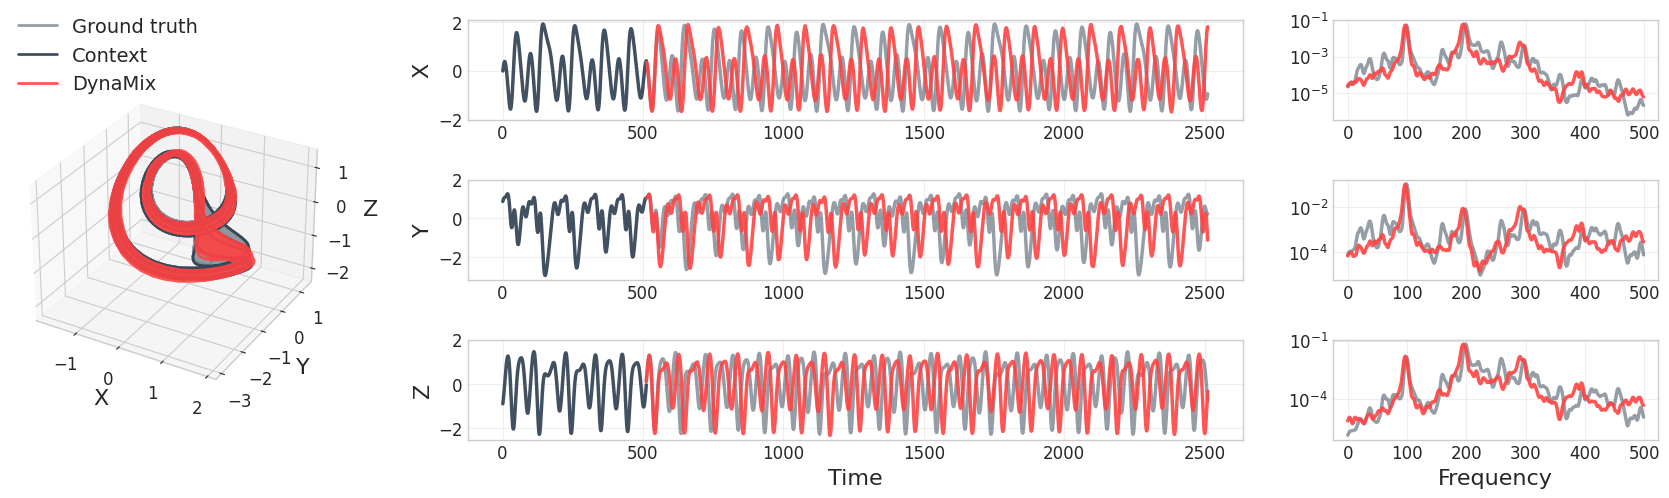

In [11]:
ground_truth_tensor = torch.tensor(ground_truth[:T,:], dtype=torch.float32)
reconstruction_tensor = torch.tensor(reconstruction_np[:T,:], dtype=torch.float32)

# Calculate metrics
bins = 30
smoothing = 20
mase_steps = 10

dstsp = geometrical_misalignment(reconstruction_tensor, ground_truth_tensor, n_bins=bins)
dh = temporal_misalignment(reconstruction_tensor, ground_truth_tensor, smoothing=smoothing)
pe = MASE(ground_truth_tensor, reconstruction_tensor, steps=mase_steps)

print(f"Geometrical Disagreement: D_stsp = {dstsp:.6f}")
print(f"Temporal Disagreement: D_H = {dh:.6f}")
print(f"Prediction Error: MASE = {pe:.6f}")

# Visualize the 3D attractor with time series and power spectrum
fig = plot_3D_attractor(context[:CL,:], reconstruction_np[:,:],ground_truth=ground_truth[:T,:],lim_pse=500)
plt.show()

## 2D Dynamical System Reconstruction

In [12]:
T = 100
initial = torch.tensor([1.0, -1.0], dtype=torch.float32)

# Load the Selkov data
context_2d = torch.tensor(np.load("test_data/selkov.npy"), dtype=torch.float32)

print("Context shape: ", context_2d.shape)
print("Initial shape: ", initial.shape)

Context shape:  torch.Size([135, 2])
Initial shape:  torch.Size([2])


In [13]:
# Make prediction
with torch.no_grad():  # No gradient tracking needed for inference
    reconstruction_2d = forecaster.forecast(
        context=context_2d,
        horizon=T,
        initial_x=initial,
        preprocessing_method="zero_embedding",
        standardize=False,
    )
    
# Convert to numpy for plotting
reconstruction_2d_np = reconstruction_2d.cpu().numpy()

print("Reconstruction shape: ", reconstruction_2d_np.shape)

Reconstruction shape:  (100, 2)


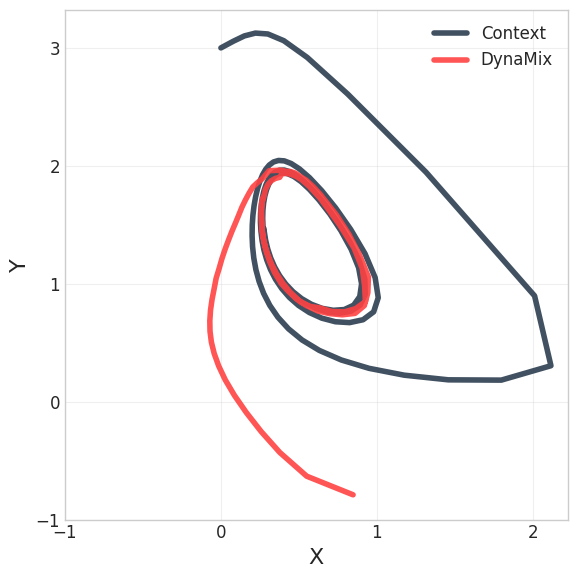

In [14]:
# Visualize the 2D attractor
fig = plot_2D_attractor(context_2d, reconstruction_2d_np)
plt.show()